# Data Audit
## Objective

The purpose of this notebook is to inspect the dataset before beginning model development.

 - Verify dataset dimensions and schema
 - identify numerical and categorical variabls
 - inspect missing and unknown values
 - evaluate target class balance
 - examine unusual or problematic vlaues
 - identify data leakage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

The dataset is the 'bank-full.csv' version of the UCI Bank Marketing dataset.
Raw data is stored in 'data/raw'.

In [2]:
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Data Structure

In [3]:
print(df.shape)
print(df.columns)
print(df.info)

(45211, 17)
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')
<bound method DataFrame.info of        age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  

### Initial Observations

- The dataset contains 45,211 observations, 17 features
- Target variable is 'y'

Duplicated Rows

In [4]:
df. duplicated().sum()

np.int64(0)

### Duplicated Observations

There are 0 duplicated rows.

## Data Types and Feature Groups

In [5]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print("Numeric Features")
print(numeric_cols)
print("")
print("Number of numeric features: ", len(numeric_cols))

Numeric Features
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Number of numeric features:  7


In [6]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Categorical Features")
print(categorical_cols)
print("")
print("Number of categorical features: ", len(categorical_cols))

Categorical Features
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Number of categorical features:  10


In [7]:
## Numeric Feature Summary

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


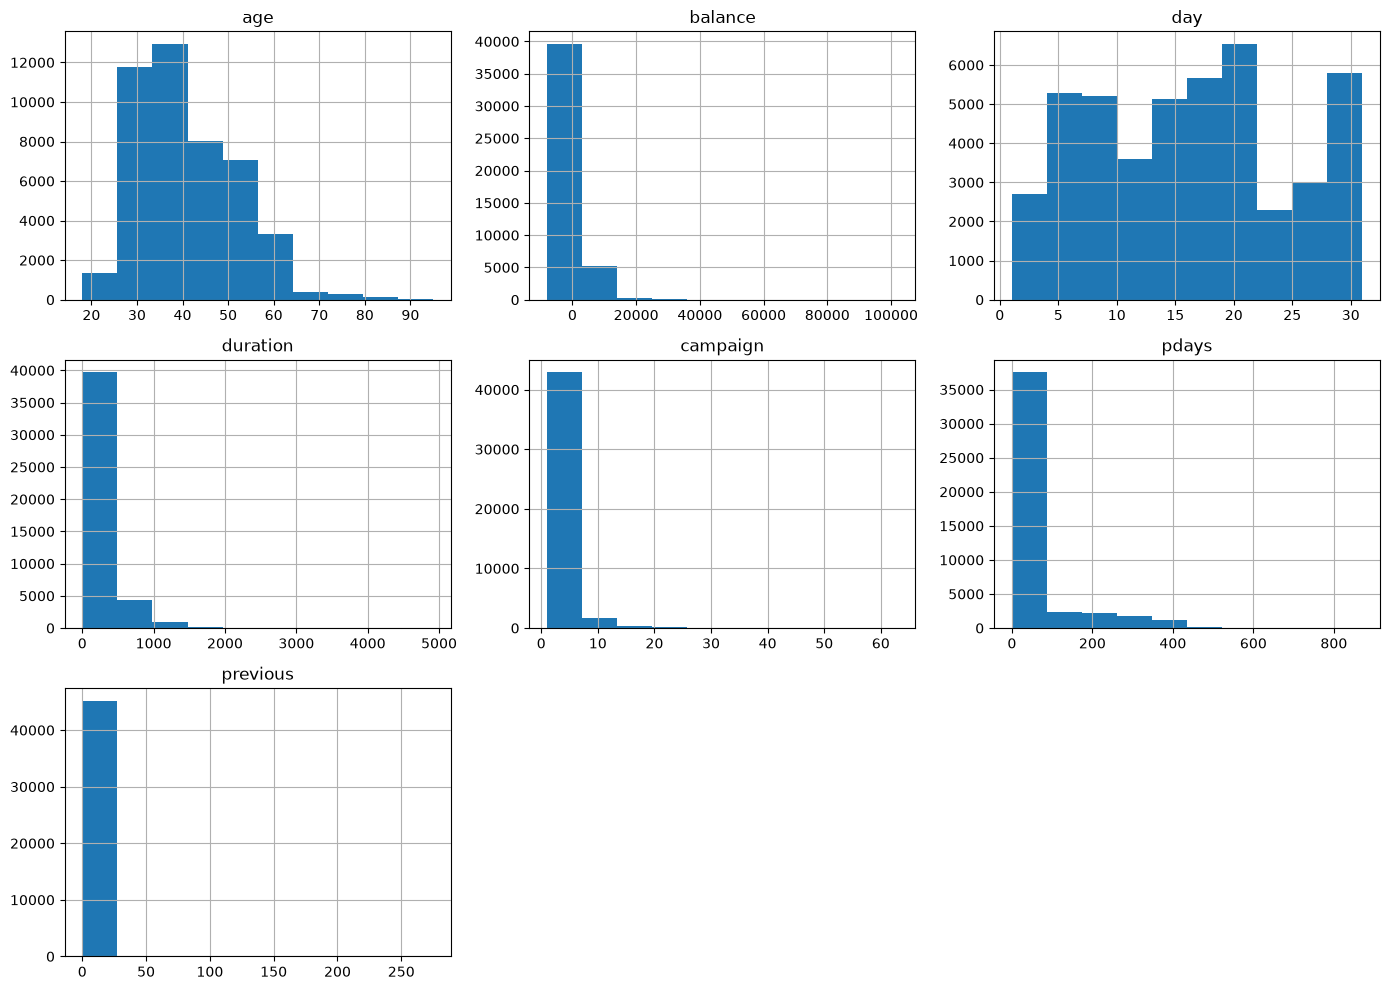

In [9]:
df[numeric_cols].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

In [10]:
## Categorical Feature Summary

In [11]:
for col in categorical_cols:
    print(df[col].value_counts())
    print(f"\n")

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


default
no     44396
yes      815
Name: count, dtype: int64


housing
yes    25130
no     20081
Name: count, dtype: int64


loan
no     37967
yes     7244
Name: count, dtype: int64


contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


poutcome
unknown    36959
failure 

In [12]:
for col in categorical_cols:
    print(df[col].value_counts(normalize=True))
    print(f"\n")

job
blue-collar      0.215257
management       0.209197
technician       0.168034
admin.           0.114375
services         0.091880
retired          0.050076
self-employed    0.034925
entrepreneur     0.032890
unemployed       0.028820
housemaid        0.027427
student          0.020747
unknown          0.006370
Name: proportion, dtype: float64


marital
married     0.601933
single      0.282896
divorced    0.115171
Name: proportion, dtype: float64


education
secondary    0.513194
tertiary     0.294198
primary      0.151534
unknown      0.041074
Name: proportion, dtype: float64


default
no     0.981973
yes    0.018027
Name: proportion, dtype: float64


housing
yes    0.555838
no     0.444162
Name: proportion, dtype: float64


loan
no     0.839774
yes    0.160226
Name: proportion, dtype: float64


contact
cellular     0.647741
unknown      0.287983
telephone    0.064276
Name: proportion, dtype: float64


month
may    0.304483
jul    0.152507
aug    0.138174
jun    0.118135
nov    0.

In [13]:
categorical_summary = pd.DataFrame ({
    "n_unique": df[categorical_cols].nunique(),
    "most_common": [
        df[col].mode()[0] for col in categorical_cols
    ]
})

print(categorical_summary)

           n_unique  most_common
job              12  blue-collar
marital           3      married
education         4    secondary
default           2           no
housing           2          yes
loan              2           no
contact           3     cellular
month            12          may
poutcome          4      unknown
y                 2           no


## Missing and Unknown Values

In [14]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Panda reports no conventional missing values, but several categorical values use the string '" unknown"' to represent unavailable or unspecified information. 

In [15]:
unknown_counts = (df == "unknown").sum()
unknown_counts[unknown_counts > 0]

job            288
education     1857
contact      13020
poutcome     36959
dtype: int64

In [16]:
unknown_summary = pd.DataFrame ({
    "count": (df == "unknown").sum(),
    "percent": (df == "unknown").mean() * 100
})

print(unknown_summary[unknown_summary["count"] > 0])

           count    percent
job          288   0.637013
education   1857   4.107407
contact    13020  28.798301
poutcome   36959  81.747805


4 features have unknown values. '"poutcome"' and '"contact"' have a relatively high percentages of unkonwn values.

## Target Variable Summary

In [17]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [18]:
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

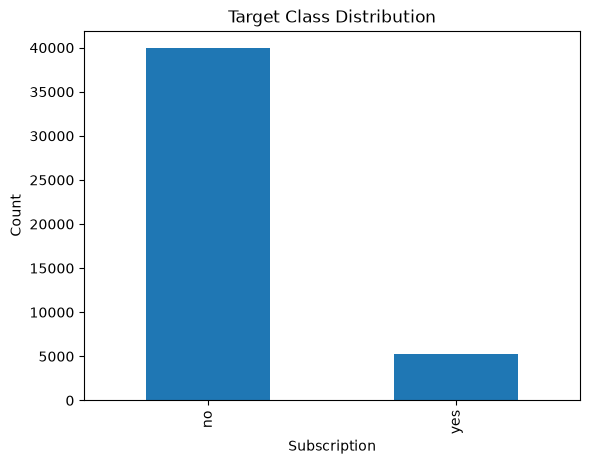

In [19]:
df["y"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

In [20]:
majority_class_accuracy = df["y"].value_counts(normalize=True).max()

print(majority_class_accuracy)

0.8830151954170445


A classifer that predicts the majority class ('no') for every observation would acheive and approximate accuracy of 88%.

This makes using model accuracy alot to evaluate model quality more challenging.

## Instect Target Relationships

Just lightly exploring the relationship between a few variables and the target.

In [21]:
pd.crosstab(df["job"], df["y"], normalize="index")

y,no,yes
job,,
admin.,0.877973,0.122027
blue-collar,0.927250,0.072750
entrepreneur,0.917283,0.082717
housemaid,0.912097,0.087903
management,0.862444,0.137556
retired,0.772085,0.227915
self-employed,0.881571,0.118429
services,0.911170,0.088830
student,0.713220,0.286780


In [22]:
pd.crosstab(df["marital"], df["y"], normalize="index")

y,no,yes
marital,,
divorced,0.880545,0.119455
married,0.898765,0.101235
single,0.850508,0.149492


In [23]:
df.groupby("y")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,40.838986,10.172662,18.0,33.0,39.0,48.0,95.0
yes,5289.0,41.670070,13.497781,18.0,31.0,38.0,50.0,95.0


## Leakage

### 'duration'

'duration' represents the duration of the most recent contact. The final duraction of a phone call isn't known till after the call has occured and it is known if the customer has subscribed or not. The intended model would be most useful being able to predict prior to that call. Will leave this variable in the raw data, may include in some additional experiments.

## Ranges

In [24]:
for col in numeric_cols:
    print(
        col,
        df[col].min(),
        df[col].max()
    )

age 18 95
balance -8019 102127
day 1 31
duration 0 4918
campaign 1 63
pdays -1 871
previous 0 275


## Data Dictionary

| Variable | Type | Meaning | Initial concerns |
| --- | --- | --- | --- |
| age | numberic | customer age |  |
| job | categorial | customer occupation | contains uknowns |
| marital | categorical | marital status | note divorced mean divorced or widowsed |
| education | categorical | costomer highest education  level | contains uknowns |
| balance | numeric | yearly account balance | inspect distribution |
| housing | binary | has housing loan |   |
| loan | binary | has personal loan |   |
| contact | categorical | contact communication type | contains unknowns |
| day | numeric | last contact day of the month |   |
| month | categorical | last contact month of year |  |
| duration | numeric | last contact duration in seconds | possible leakage |
| campaign | numeric | number of contacts performed during campaign for this client | includes last contact |
| pdays | numeric | numer of days that passed by after the client was last contacted from a previous campaign | -1 means client was not previously contacted |
| previous | numeric | numer of contacts performed before this campaign and for this client |  |
| poutcome | categorical | outcome of previous marketing campaign | contains uknowns |
| y | binary | subscribed to depostic | target|

## Conclusions

### Dataset
- 45,211 observations
- 16 predictor variables
- binary target: `y`

### Target
- The target is imbalanced toward `no`.
- A majority-class baseline achieves approximately 88% accuracy.
- Accuracy therefore cannot be used as the sole performance metric.

### Missingness
- No standard NaN values were detected.
- Several categorical variables contain `"unknown"` values.
- These will require preprocessing.

### Feature distributions
- Several numerical features are strongly skewed.
- Some features contain extreme values that require interpretation.
  
### Leakage concerns
- `duration` would not be available before the completion of a call.
- Its inclusion depends on the intended prediction point.

### Planned next steps
1. Define the prediction point explicitly.
2. Separate predictors and target.
3. Create a stratified train/test split.
4. Preserve the test set untouched.
5. Build a majority-class baseline.
6. Develop preprocessing inside sklearn pipelines.